# 1. Khai báo thư viện ảnh

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as PhamThanhTung
from google.colab.patches import cv2_imshow
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift
from sklearn.cluster import KMeans
from itertools import permutations

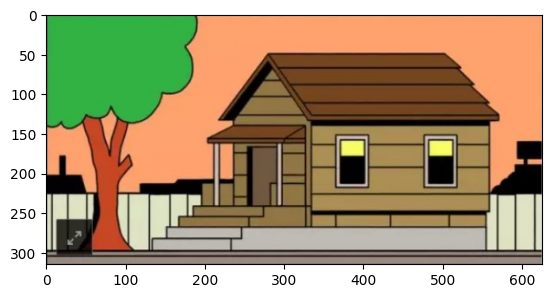

In [2]:
img = cv2.imread('example.jpg')
PhamThanhTung.imshow(img[:,:,::-1])

# 2. Harris Corner Detection

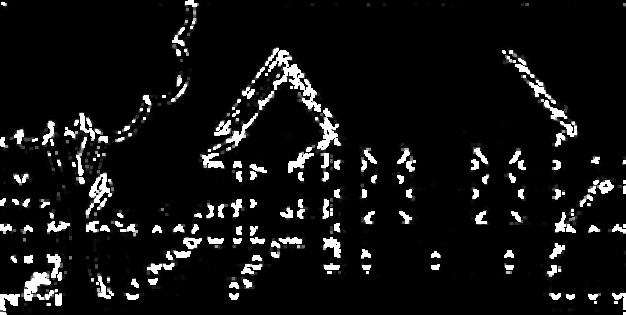

In [3]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray) # chuyển ảnh sang kiểu float32 để sử dụng với hàm cornerHarris
dst = cv2.cornerHarris(gray,2,3,0.04) # dùng phương pháp Harris corner detection (blockSize=2, ksize=3, k=0.04)
dst = cv2.dilate(dst,None) # làm dày các điểm góc để dễ dàng hiển thị

img[dst>0.01*dst.max()]=[0,0,255] # các điểm góc có giá trị lớn hơn 1% của giá trị lớn nhất sẽ được đánh dấu là các gốc
cv2_imshow(dst)

# 3. Band-pass filtering by Difference of Gaussians

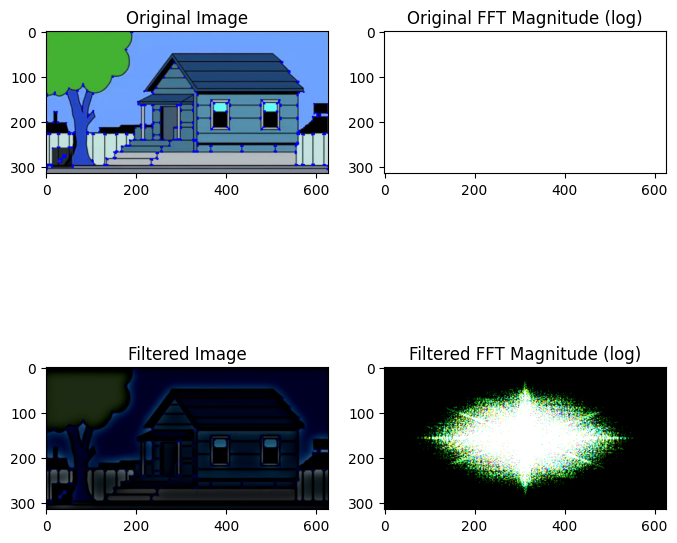

In [4]:
wimage = img * window('hann', img.shape)  # áp dụng cửa sổ Hann để giảm nhiễu biên
filtered_image = difference_of_gaussians(img, 1, 12) # áp dụng bộ lọc Difference of Gaussians để làm nổi bật các chi tiết ở các tần số khác nhau
filtered_wimage = filtered_image * window('hann', img.shape) # áp dụng cửa sổ Hann cho ảnh đã lọc để giảm nhiễu biên trước khi tính FFT
im_f_mag = fftshift(np.abs(fftn(wimage))) # tính FFT của ảnh đã áp dụng cửa sổ và lấy giá trị tuyệt đối, sau đó dịch chuyển tần số thấp về trung tâm
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage))) # tính FFT của ảnh đã lọc và áp dụng cửa sổ, lấy giá trị tuyệt đối và dịch chuyển tần số thấp về trung tâm

fig, ax = PhamThanhTung.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(img, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
PhamThanhTung.show()

# biểu đồ "Original FFT Magnitude" trắng tinh có thể do giá trị ở điểm trung tâm có thethể có giá trị cao hơn nhiều so với các tần số cao ở rìa

# 4. Automatic Scale Selection

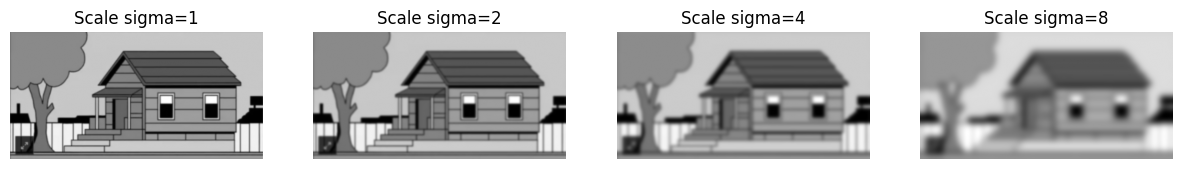

In [5]:
# tạo nhiều scale Gaussian
scales = [1,2,4,8]

fig,axs = PhamThanhTung.subplots(1,len(scales),figsize=(15,5)) # tạo một hàng các subplot để hiển thị kết quả của các scale khác nhau

for i,s in enumerate(scales): # lặp qua các scale và áp dụng Gaussian blur với sigma tương ứng

    blur = cv2.GaussianBlur(gray,(0,0),s) # áp dụng Gaussian blur với kernel size tự động (0,0) và sigma bằng s

    axs[i].imshow(blur,cmap='gray') # hiển thị ảnh đã được làm mờ trên subplot tương ứng
    axs[i].set_title(f"Scale sigma={s}")
    axs[i].axis("off")

PhamThanhTung.show()

# 5. Scale Invariant Detection

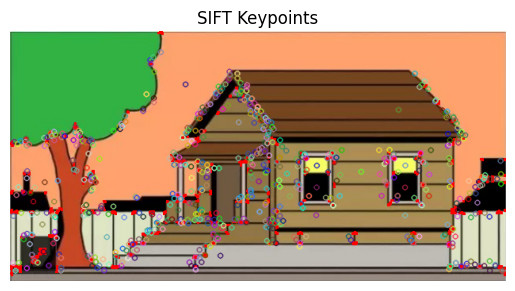

In [6]:
# tạo lại ảnh grayscale chuẩn uint8
gray_sift = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# khởi tạo SIFT
sift = cv2.SIFT_create()

# tính toán keypoints và descriptors bằng SIFT
kp, des = sift.detectAndCompute(gray_sift, None)

# vẽ keypoints
img_sift = cv2.drawKeypoints(img, kp, None)

PhamThanhTung.imshow(img_sift[:,:,::-1]) # chuyển đổi từ BGR sang RGB để hiển thị đúng màu sắc
PhamThanhTung.title("SIFT Keypoints")
PhamThanhTung.axis("off")
PhamThanhTung.show()

# 6. Scale-space Blob Detector

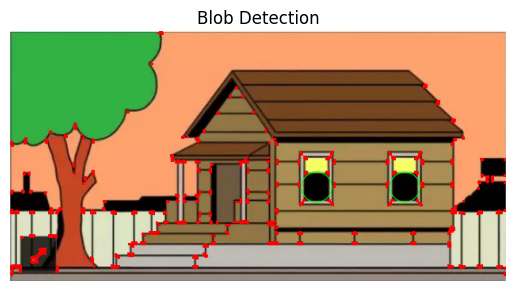

In [7]:
# tạo lại ảnh grayscale chuẩn
gray_blob = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# thiết lập tham số cho blob detection
params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True # chỉ phát hiện blob có diện tích lớn hơn một ngưỡng nhất định
params.minArea = 100 # ngưỡng diện tích tối thiểu của blob

# tạo detector với các tham số đã thiết lập
detector = cv2.SimpleBlobDetector_create(params)

# phát hiện blob trong ảnh
keypoints = detector.detect(gray_blob)

# vẻ blob lên ảnh gốc
img_blob = cv2.drawKeypoints(
    img,
    keypoints,
    np.array([]),
    (0,255,0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

PhamThanhTung.imshow(img_blob[:,:,::-1])
PhamThanhTung.title("Blob Detection")
PhamThanhTung.axis("off")
PhamThanhTung.show()

# 7. Bag-of-Words Detection

In [8]:
# dùng descriptor SIFT làm đặc trưng cho các keypoints đã phát hiện
descriptors = des

# set clustering thành visual words
k = 20 # số lượng visual words (cluster)
kmeans = KMeans(n_clusters=k) # khởi tạo KMeans với số lượng cluster bằng k đã tạo

kmeans.fit(descriptors) # thực hiện clustering trên các descriptor để tạo visual vocabulary

print("Tạo visual vocabulary:", k)

Tạo visual vocabulary: 20


# 8. Image Panorama (ghép ảnh)

In [9]:
def stitch(img1, img2): # hàm ghép hai ảnh img1 và img2 với nhau bằng cách tìm phần chồng lấn tốt nhất giữa hai ảnh
                        # dựa trên Mean Squared Error (MSE) và sau đó thực hiện blending để tạo ra một ảnh panorama liền mạch
    h, w1, w2 = img1.shape[0], img1.shape[1], img2.shape[1] # lấy chiều cao và chiều rộng của hai ảnh

    best_mse, best_ov = 1e9, 0 # khởi tạo giá trị MSE và độ chồng lấn
    for ov in range(5, min(w1, w2)): # lặp qua các giá trị độ chồng lấn từ 5 pixel đến độ rộng nhỏ hơn của hai ảnh
                                        # ov (overlap): độ rộng vùng chồng lấn
        s1 = img1[h//3:, w1-ov:].astype(np.float32) # lấy phần ảnh nghi ngờ bị chồng lấn (overlap) giữa hai ảnh để so sánh
                                                    # bằng Mean Squared Error (MSE), chuyển sang dạng float32 để dễ dàng tính toán hơn
                                                    # h//3: lấy 2/3 phần dưới của ảnh, w1-ov: lấy ov pixel cuối cùng bên phải của img1

        s2 = img2[h//3:, :ov].astype(np.float32)
        mse = np.mean((s1 - s2) ** 2) # tính Mean Squared Error (MSE) giữa hai phần ảnh chồng lấn s1 và s2, MSE càng nhỏ
                                        #thì hai phần ảnh càng giống nhau, nghĩa là độ chồng lấn của 2 ảnh tốt hơn
        if mse < best_mse:  # nếu MSE hiện tại nhỏ hơn MSE tốt nhất ở trên , cập nhật giá trị MSE tốt nhất và độ chồng lấn tương ứng
            best_mse, best_ov = mse, ov

    print(f"Overlap: {best_ov}px")

    canvas = np.zeros((h, w1 + w2 - best_ov, 3), dtype=np.uint8) # tạo một canvas mới có kích thước đủ để chứa cả hai ảnh sau khi ghép,
                                                                    # chiều rộng được tính bằng tổng chiều rộng của hai ảnh trừ đi phần chồng lấn đã tìm được
    canvas[:, :w1] = img1 # sao chép img1 vào phần đầu của canvas

    # kết hợp hai ảnh bằng cách sử dụng linear blending trong vùng chồng lấn để tạo một phần chuyển tiếp giữa hai ảnh
    for x in range(best_ov):
        alpha = x / max(best_ov - 1, 1) # tính hệ số alpha cho linear blending, alpha thay đổi tuyến tính từ 0 đến 1 qua vùng chồng lấn,
                                        # giúp tạo ra sự chuyển tiếp mượt mà giữa hai ảnh
        canvas[:, w1 - best_ov + x] = (                 # kết hợp pixel từ 2 ảnh img1 và img2 trong vùng chồng lấn bằng cách sử dụng hệ số alpha để tạo hiệu ứng blendinf
            (1 - alpha) * img1[:, w1 - best_ov + x] +   # hệ số (1 - alpha) nhân với pixel từ img1 tại vị trí tương ứng trong vùng chồng lấn
            alpha * img2[:, x]                          # hệ số alpha nhân với pixel từ img2 tại vị trí tương ứng trong vùng chồng lấn
        ).astype(np.uint8)                              # chuyển kết quả về uint8 để đảm bảo định dạng ảnh hợp lệ

    canvas[:, w1:] = img2[:, best_ov:]                  # sao chép phần còn lại của img2 vào canvas sau vùng chồng lấn
    return canvas

In [10]:
def draw_feature_matches(img1, img2):                   # hàm này sử dụng thuật toán ORB để phát hiện và mô tả các keypoints trong hai ảnh, sau đó sử dụng Brute-Force Matcher
                                                        # để tìm các điểm tương đồng giữa hai bộ descriptor và vẽ các điểm tương đồng lên một ảnh kết quả
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)      # chuyển 2 ảnh về grayscale để sử dụng với ORB
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(1000)                          # khởi tạo ORB với số lượng keypoints tối đa là 1000 để tránh hiện tượng tràn ram

    kp1, des1 = orb.detectAndCompute(gray1, None)       # phát hiện keypoints và tính toán descriptors cho hai ảnh bằng ORB
    kp2, des2 = orb.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)   # khởi tạo Brute-Force Matcher với khoảng cách Hamming và chế độ crossCheck
                                                            # để đảm bảo rằng mỗi điểm trong des1 chỉ được ghép với một điểm duy nhất trong des2 và ngược lại
    matches = bf.match(des1, des2)

    matches = sorted(matches, key=lambda x: x.distance)     # sắp xếp các điểm tương đồng theo khoảng cách (distance) giữa các descriptor
                                                            # khoảng cách nhỏ hơn cho thấy sự tương đồng tốt hơn

    match_img = cv2.drawMatches(                            # vẽ các điểm tương đồng lên một ảnh kết quả bằng cách sử dụng hàm drawMatches của OpenCV
                                                            # chỉ vẽ 50 điểm tương đồng tốt nhất
        img1, kp1,
        img2, kp2,
        matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return match_img

In [11]:
img1 = cv2.imread("example1.jpg")
img2 = cv2.imread("example2.jpg")

match_img = draw_feature_matches(img1, img2)            # vẽ các điểm tương đồng giữa hai ảnh để kiểm tra xem hai ảnh có đủ điểm tương đồng để ghép hay không

panorama = stitch(img1, img2)                           # ghép hai ảnh lại với nhau để tạo thành một ảnh panorama
cv2.imwrite("panorama_output.jpg", panorama)

match_img = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)
panorama = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

Overlap: 5px


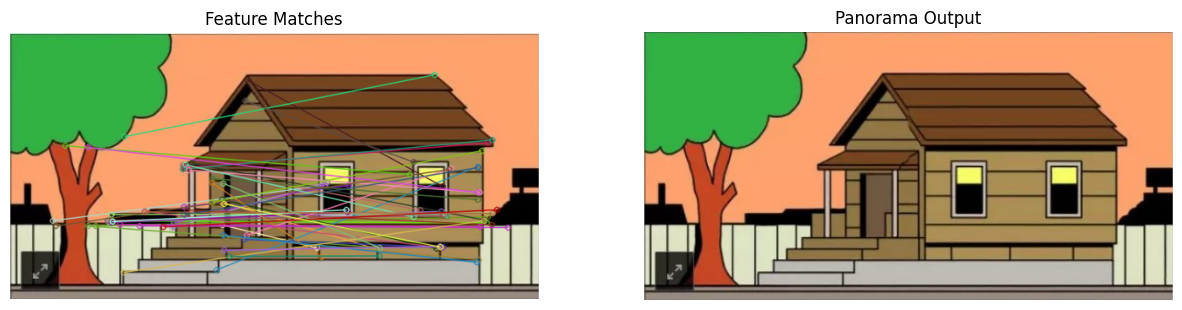

In [12]:
# Plot kết quả
PhamThanhTung.figure(figsize=(15,6))

PhamThanhTung.subplot(1,2,1)
PhamThanhTung.title("Feature Matches")
PhamThanhTung.imshow(match_img)
PhamThanhTung.axis("off")

PhamThanhTung.subplot(1,2,2)
PhamThanhTung.title("Panorama Output")
PhamThanhTung.imshow(panorama)
PhamThanhTung.axis("off")

PhamThanhTung.show()

# 9. Ghép ảnh Automatic mosaicing

In [13]:
def overlap_score(img_left, img_right):             # hàm tính toán độ chồng lấp giữa hai ảnh
    h = img_left.shape[0]                           # lấy chiều cao của ảnh bên trái để xác định vùng chồng lấn, thường là phần dưới của ảnh để tránh các chi tiết có thể khác nhau ở phần trên
    w1, w2 = img_left.shape[1], img_right.shape[1]  # lấy chiều rộng của hai ảnh để xác định phạm vi có thể có của vùng chồng lấn, thường là phần bên phải của ảnh bên trái và phần bên trái của ảnh bên phải

    best_mse, best_ov = 1e9, 0
    for ov in range(5, min(w1, w2)):                # giống bài 8, lập lại quá trình tìm kiếm độ chông chất
        s1 = img_left[h//3:, w1-ov:].astype(np.float32)
        s2 = img_right[h//3:, :ov].astype(np.float32)

        mse = np.mean((s1 - s2) ** 2)

        if mse < best_mse:
            best_mse, best_ov = mse, ov

    return best_mse, best_ov

In [14]:
def stitch_pair(img_left, img_right, overlap): # hàm để tính việc ghép 2 hình với nhau
    h, w1, w2 = img_left.shape[0], img_left.shape[1], img_right.shape[1]        # lấy chiều cao và chiều rộng của hai ảnh để xác định
                                                                                # kích thước của canvas mới và vị trí chồng lấn

    canvas = np.zeros((h, w1 + w2 - overlap, 3), dtype=np.uint8)                # tạo canvas mới để chứa ảnh ghép
    canvas[:, :w1] = img_left

    for x in range(overlap):                        # kết hợp hai ảnh bằng cách sử dụng linear blending
                                                    # trong vùng chồng lấn để tạo một phần chuyển tiếp giữa hai ảnh
        alpha = x / max(overlap - 1, 1)

        canvas[:, w1 - overlap + x] = (             # canvas tại vị trí chồng lấn được tính bằng cách kết hợp pixel từ
                                                # img_left và img_right với hệ số alpha để tạo hiệu ứng blending
            (1 - alpha) * img_left[:, w1 - overlap + x] +
            alpha * img_right[:, x]
        ).astype(np.uint8)

    canvas[:, w1:] = img_right[:, overlap:]

    return canvas

In [15]:
def draw_feature_matches(img1, img2):           # hàm dùng thuật toán ORB để phát hiện và mô tả các keypoints trong hai ảnh,
                                                # sau đó sử dụng Brute-Force Matcher để nối các điểm đó lại với nhua
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)          # chuyển 2 ảnh về grayscale để sử dụng với ORB
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(1000)               # khởi tạo ORB với số lượng keypoints tối đa là 1000 để tránh hiện tượng tràn ram

    kp1, des1 = orb.detectAndCompute(gray1, None)    # phát hiện keypoints và tính toán descriptors cho hai ảnh bằng ORB
    kp2, des2 = orb.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)       # khởi tạo Brute-Force Matcher với Norm_Hamming và
                                                                # chế độ crossCheck để đảm bảo rằng mỗi điểm trong des1
                                                                # chỉ được ghép với một điểm duy nhất trong des2 và ngược lại
    matches = bf.match(des1, des2)

    matches = sorted(matches, key=lambda x: x.distance)     # sắp xếp các điểm tương đồng theo khoảng cách giữa các descriptor
                                                            # khoảng cách nhỏ hơn cho thấy sự tương đồng tốt hơn

    match_img = cv2.drawMatches(             # vẽ các điểm tương đồng lên một ảnh kết quả bằng cách sử dụng hàm drawMatches của OpenCV
        img1, kp1,
        img2, kp2,
        matches[:50], None,                     # set tối đa 50 điểm tương đồng tốt nhất
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS       # cắm cờ để chỉ vẽ các đường nối giữa các điểm tương đồng
                                                                # mà không vẽ các keypoint đơn lẻ không có đối tác tương đồng nào
    )

    return match_img

In [16]:
# Load images
images = {
    "example1.jpg": cv2.imread("example1.jpg"),
    "example2.jpg": cv2.imread("example2.jpg"),
}

names = list(images.keys()) # tạo một danh sách chứa tên của các ảnh để dễ dàng truy cập và hiển thị kết quả sau này
imgs = list(images.values())

In [17]:
best_score, best_order, best_ov = 1e9, None, 0      # khởi tạo giá trị tốt nhất cho điểm số (score),
                                                    # thứ tự ảnh (order) và độ chồng lấn (overlap)
                                                    # để so sánh và tìm ra cặp ảnh có độ chồng lấn tốt nhất

for perm in permutations(range(len(imgs))):         # lặp qua tất cả các hoán vị của chỉ số ảnh để
                                                    # tìm ra cặp ảnh có độ chồng lấn tốt nhất bằng cách sử dụng hàm overlap_score
    score, ov = overlap_score(imgs[perm[0]], imgs[perm[1]])

    if score < best_score:      # nếu điểm số hiện tại tốt hơn điểm số tốt nhất đã lưu
                                # cập nhật giá trị tốt nhất cho điểm số, thứ tự ảnh và độ chồng lấn
        best_score = score
        best_order = perm
        best_ov = ov

# chọn ảnh bên trái và bên phải dựa trên thứ tự tốt nhất đã tìm được từ quá trình đánh giá độ chồng lấn
img_left = imgs[best_order[0]]
img_right = imgs[best_order[1]]

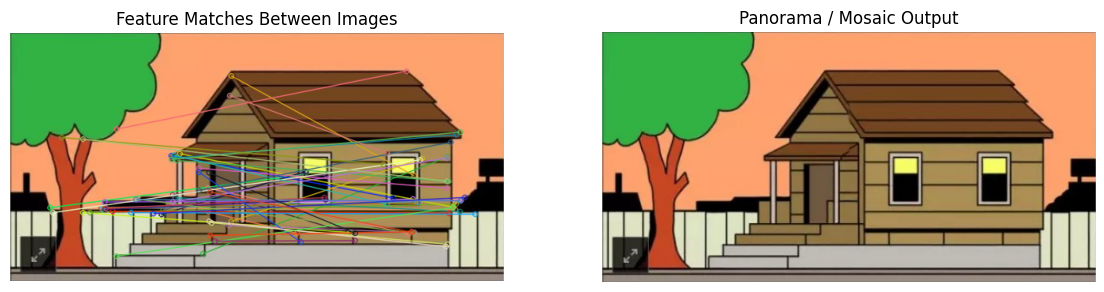

In [18]:
# vẽ các điểm tương đồng giữa hai ảnh để kiểm tra xem hai ảnh có đủ điểm tương đồng giữa 2 ảnh
match_img = draw_feature_matches(img_left, img_right)

# ghép ảnh với nhau sử dụng hàm stitch_pair với độ chồng lấn tốt nhất đã tìm được
result = stitch_pair(img_left, img_right, best_ov)

cv2.imwrite("mosaic_output.jpg", result)    # lưu ảnh kết quả sau khi ghép vào file "mosaic_output.jpg"

# chuyển đổi từ BGR sang RGB để hiển thị đúng màu sắc trong matplotlib
match_img = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# plot kết quả
PhamThanhTung.figure(figsize=(14,6))

PhamThanhTung.subplot(1,2,1)
PhamThanhTung.title("Feature Matches Between Images")
PhamThanhTung.imshow(match_img)
PhamThanhTung.axis("off")

PhamThanhTung.subplot(1,2,2)
PhamThanhTung.title("Panorama / Mosaic Output")
PhamThanhTung.imshow(result)
PhamThanhTung.axis("off")

PhamThanhTung.show()

# 10. Sử dụng Wide base-line stereo

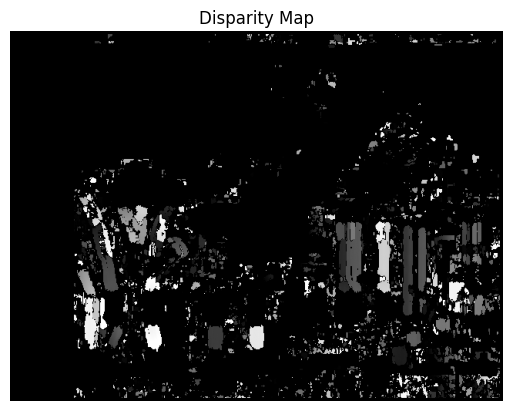

In [19]:
# đọc ảnh
imgL = cv2.imread("example1.jpg")
imgR = cv2.imread("example2.jpg")

# chuyển sang grayscale
grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# resize cho ổn định
grayL = cv2.resize(grayL,(640,480))
grayR = cv2.resize(grayR,(640,480))

# stereo matching
stereo = cv2.StereoBM_create(numDisparities=16*5, blockSize=9)

# tính toán bản đồ disparity giữa hai ảnh bằng cách sử dụng đối tượng stereo đã tạo
# kết quả là một ảnh grayscale thể hiện sự khác biệt về vị trí của các điểm tương ứng giữa hai ảnh
disparity = stereo.compute(grayL, grayR)

PhamThanhTung.imshow(disparity, cmap='gray')
PhamThanhTung.title("Disparity Map")
PhamThanhTung.axis("off")
PhamThanhTung.show()

# 11. CBIR (content-based image retrieval)

In [20]:
# khai báo danh sách ảnh database
database = [
    "example.jpg",
    "example1.jpg",
    "example2.jpg",
    "mosaic_output.jpg",
    "panorama_output.jpg"
]


In [21]:
# chọn query image
query_path = "example1.jpg"

query_img = cv2.imread(query_path)
query_gray = cv2.cvtColor(query_img, cv2.COLOR_BGR2GRAY)

In [22]:
# khởi tạo SIFT detector
sift = cv2.SIFT_create()

# Trích xuất keypoints và descriptors của query
kp_q, des_q = sift.detectAndCompute(query_gray, None)

# BFMatcher dùng để so sánh descriptor
bf = cv2.BFMatcher()

results = []

In [23]:
# so sánh query với database
for path in database:

    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # tính toán keypoints và descriptors của ảnh trong database
    kp, des = sift.detectAndCompute(gray, None)

    # KNN matching giữa descriptor của query và descriptor của ảnh trong database để tìm các điểm tương đồng giữa hai ảnh
    matches = bf.knnMatch(des_q, des, k=2)

    # lowe ratio test để lọc match tốt
    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    # lưu kết quả
    results.append((path, len(good), img))

In [24]:
# sắp xếp theo độ giống
results = sorted(results, key=lambda x: x[1], reverse=True)

print("CBIR Results:")  # print kết quả
for r in results:
    print(r[0], "→ matches:", r[1])

CBIR Results:
example1.jpg → matches: 446
example.jpg → matches: 437
mosaic_output.jpg → matches: 417
panorama_output.jpg → matches: 417
example2.jpg → matches: 34


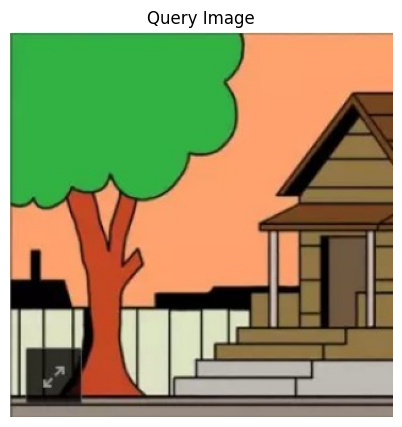

In [25]:
# hiển thị query image
PhamThanhTung.figure(figsize=(5,5))
PhamThanhTung.imshow(query_img[:,:,::-1])
PhamThanhTung.title("Query Image")
PhamThanhTung.axis("off")
PhamThanhTung.show()

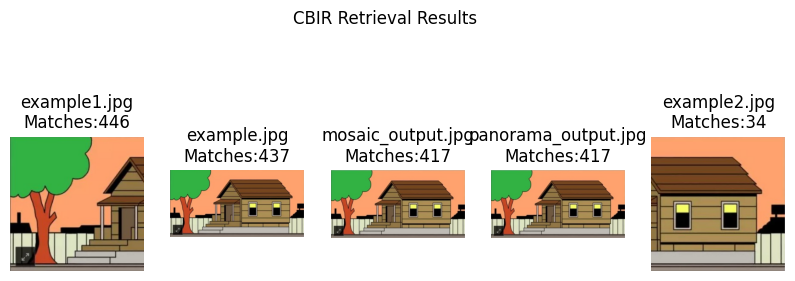

In [26]:
# hiển thị ảnh database theo thứ tự giống
PhamThanhTung.figure(figsize=(10,4))

for i, (path, score, img) in enumerate(results):

    PhamThanhTung.subplot(1, len(results), i+1)
    PhamThanhTung.imshow(img[:,:,::-1])
    PhamThanhTung.title(f"{path}\nMatches:{score}")
    PhamThanhTung.axis("off")

PhamThanhTung.suptitle("CBIR Retrieval Results")
PhamThanhTung.show()

# 12. Bag-of-word with SIFT + Histogram

In [27]:
# set dataset
image_paths = database

sift = cv2.SIFT_create()

descriptor_list = []

# trích xuất descriptor từ tất cả ảnh trong database để chuẩn bị cho quá trình so sánh với query image
for path in image_paths:

    img = cv2.imread(path)
    # Check if the image was loaded successfully
    if img is None:
        print(f"Warning: Could not load image from path: {path}. Skipping this image.")
        continue

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    kp, des = sift.detectAndCompute(gray,None)  # tính toán keypoints và descriptors của ảnh trong database bằng SIFT

    # Check if descriptors were found
    if des is None:
        print(f"Warning: No descriptors found for image: {path}. Skipping this image.")
        continue

    # lưu descriptor của ảnh vào một danh sách để sử dụng sau này trong quá trình so sánh với query image
    descriptor_list.append(des)

In [28]:
# gộp tất cả descriptor từ tất cả ảnh trong database thành một mảng lớn để thực hiện clustering và tạo visual vocabulary
all_descriptors = np.vstack(descriptor_list)

# số visual words
k = 20

# clustering để tạo visual vocabulary bằng KMeans với số lượng cluster bằng k đã set
kmeans = KMeans(n_clusters=k)
kmeans.fit(all_descriptors)

KMeans(n_clusters=20)

In [29]:
# hàm tạo histogram
def build_histogram(descriptors):

    hist = np.zeros(k)  # khởi tạo histogram với số lượng bin bằng số visual words (k)

    cluster_result = kmeans.predict(descriptors) # dự đoán cluster visual word của từng descriptor
                                                 # bằng cách sử dụng model KMeans đã được huấn luyện,

    for i in cluster_result:    # duyệt qua kết quả dự đoán cluster của từng descriptor
        hist[i] += 1        # tăng giá trị của bin tương ứng trong histogram lên 1 để đếm số lượng descriptor thuộc về mỗi visual word

    return hist

In [30]:
# histogram cho từng ảnh
histograms = []

# gộp tất cả descriptor từ tất cả ảnh trong database thành một mảng lớn để thực hiện clustering và tạo visual vocabulary
for des in descriptor_list:
    hist = build_histogram(des)
    histograms.append(hist)

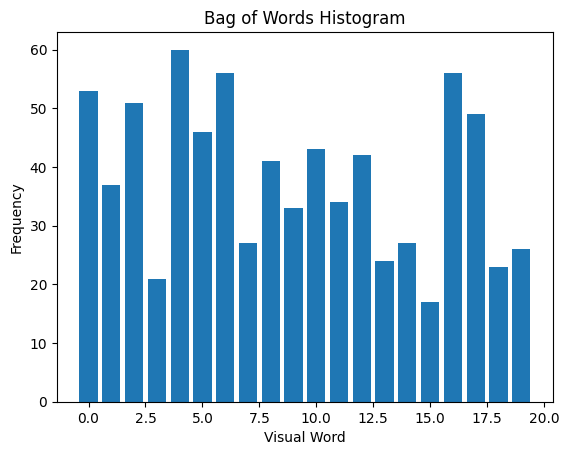

In [31]:
# hiển thị histogram
PhamThanhTung.bar(range(k),histograms[0])
PhamThanhTung.title("Bag of Words Histogram")
PhamThanhTung.xlabel("Visual Word")
PhamThanhTung.ylabel("Frequency")
PhamThanhTung.show()